# FraudShield AI: Exploratory Data Analysis & Model Comparison

## 1. Introduction
The goal of this project is to detect fraudulent credit card transactions. Due to privacy reasons, the dataset uses PCA-transformed features (V1-V28), along with `Time` and `Amount`. The `Class` column is the target variable where `1` indicates fraud and `0` indicates a legitimate transaction.

In this notebook, we generate synthetic data, perform exploratory data analysis (EDA), handle extreme class imbalance using SMOTE, and compare four different machine learning models to choose the best one for production.

## 2. Data Loading
We load the real credit card fraud dataset (`creditcard.csv`) for our exploratory data analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load real dataset
df = pd.read_csv('creditcard.csv')
print(f"Loaded real dataset with {len(df)} samples.")


Loaded real dataset with 284807 samples.


## 3. Exploratory Data Analysis (EDA)
Let's look at the general statistics, check for missing values, and inspect the distributions of our data.

In [2]:
# Basic info
display(df.head())
print("\n--- Dataset Info ---")
df.info()
print("\n--- Summary Statistics ---")
display(df.describe())
print("\n--- Missing Values ---")
print(df.isnull().sum().max()) # Show max missing values per column
print("\n--- Duplicates ---")
print(df.duplicated().sum())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



--- Missing Values ---
0

--- Duplicates ---


1081


### Class Distribution
The dataset is highly imbalanced, which is typical for fraud detection datasets. Below we plot the distribution.

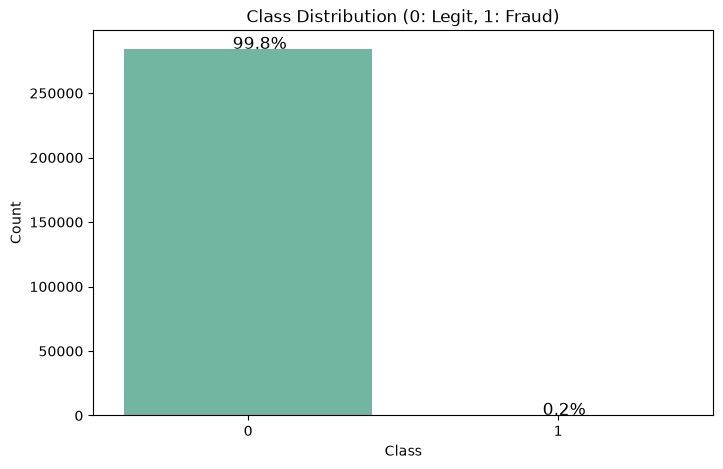

In [3]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Class', data=df, palette='Set2')
plt.title('Class Distribution (0: Legit, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), size=12)

plt.show()

### Amount Distribution
Fraudulent transactions may have a different distribution of amounts compared to legitimate ones. A boxplot helps to visualize outliers and quartile ranges.

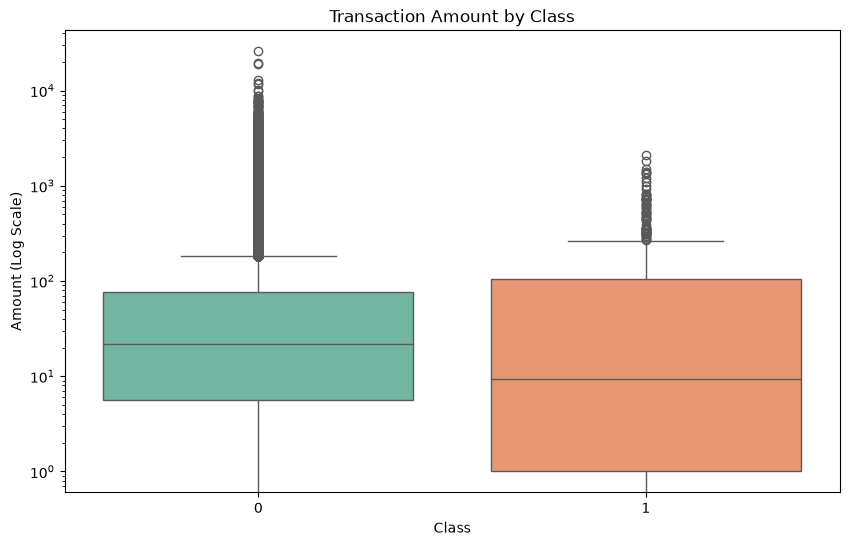

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='Amount', data=df, palette='Set2')
plt.title('Transaction Amount by Class')
plt.yscale('log') # Log scale helps handle large amount outliers
plt.ylabel('Amount (Log Scale)')
plt.show()

### Correlation Heatmap
Let's see which features correlate most with the target variable `Class` and among themselves.

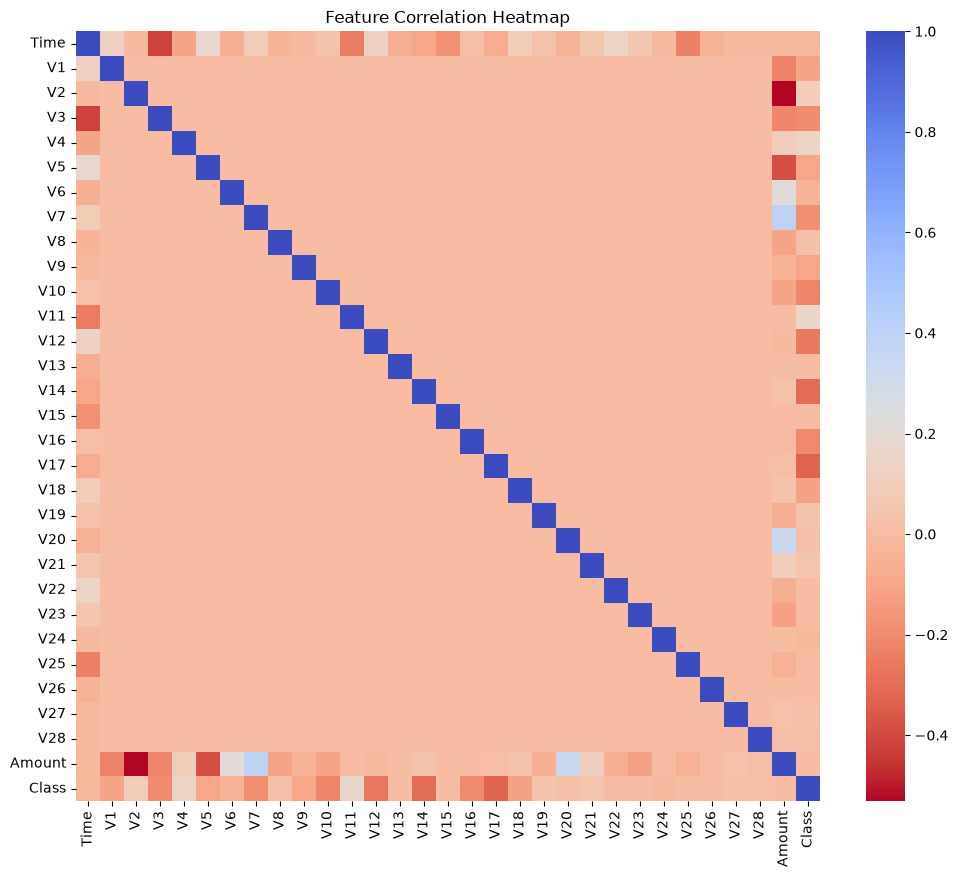

In [5]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':10})
plt.title('Feature Correlation Heatmap')
plt.show()

## 4. Class Imbalance Handling
To prevent our model from simply predicting the majority class (legit), we will oversample the minority class (fraud) using SMOTE (Synthetic Minority Over-sampling Technique) on the training set. This helps the model learn the patterns of fraudulent transactions better.

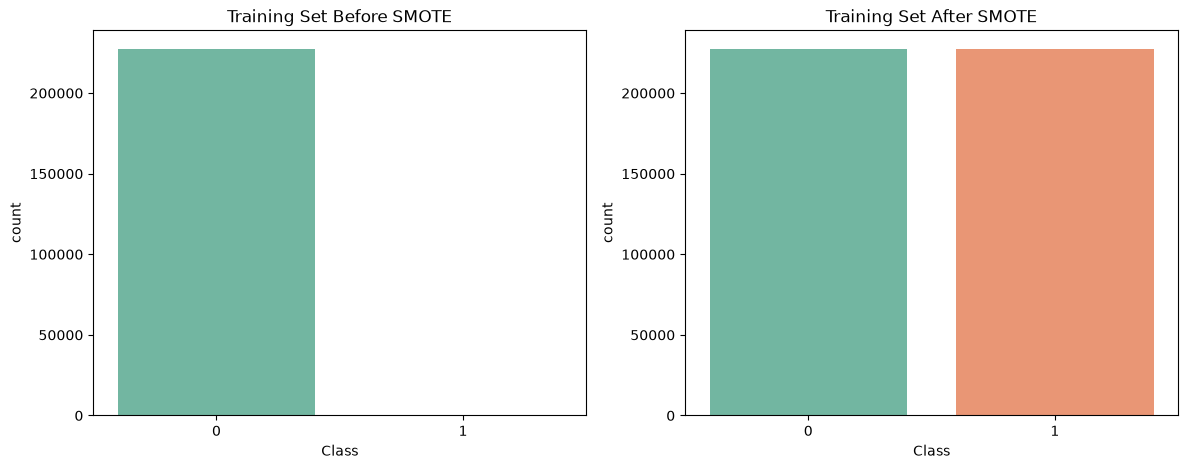

Original training shape: (227845, 30)
SMOTE training shape: (454902, 30)


In [6]:
X = df.drop('Class', axis=1)
y = df['Class']

# Split first to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
sns.countplot(x=y_train, ax=axes[0], palette='Set2')
axes[0].set_title('Training Set Before SMOTE')

# After SMOTE
sns.countplot(x=y_train_smote, ax=axes[1], palette='Set2')
axes[1].set_title('Training Set After SMOTE')

plt.show()

print(f"Original training shape: {X_train.shape}")
print(f"SMOTE training shape: {X_train_smote.shape}")

## 5. Model Comparison
We will evaluate four different algorithms to see which performs best on the task:
- Logistic Regression
- ~~Support Vector Machine (SVC)~~ *(Removed because it takes too long to train on half a million rows)*
- Random Forest
- XGBoost

Models are evaluated on Precision, Recall, F1-score, and ROC-AUC on the original (un-resampled) test set. We also plot the confusion matrices to understand false positives and false negatives.

Training Logistic Regression...



Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.11      0.90      0.20        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962

Training Random Forest...



Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Training XGBoost...



XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.40      0.89      0.55        98

    accuracy                           1.00     56962
   macro avg       0.70      0.94      0.77     56962
weighted avg       1.00      1.00      1.00     56962



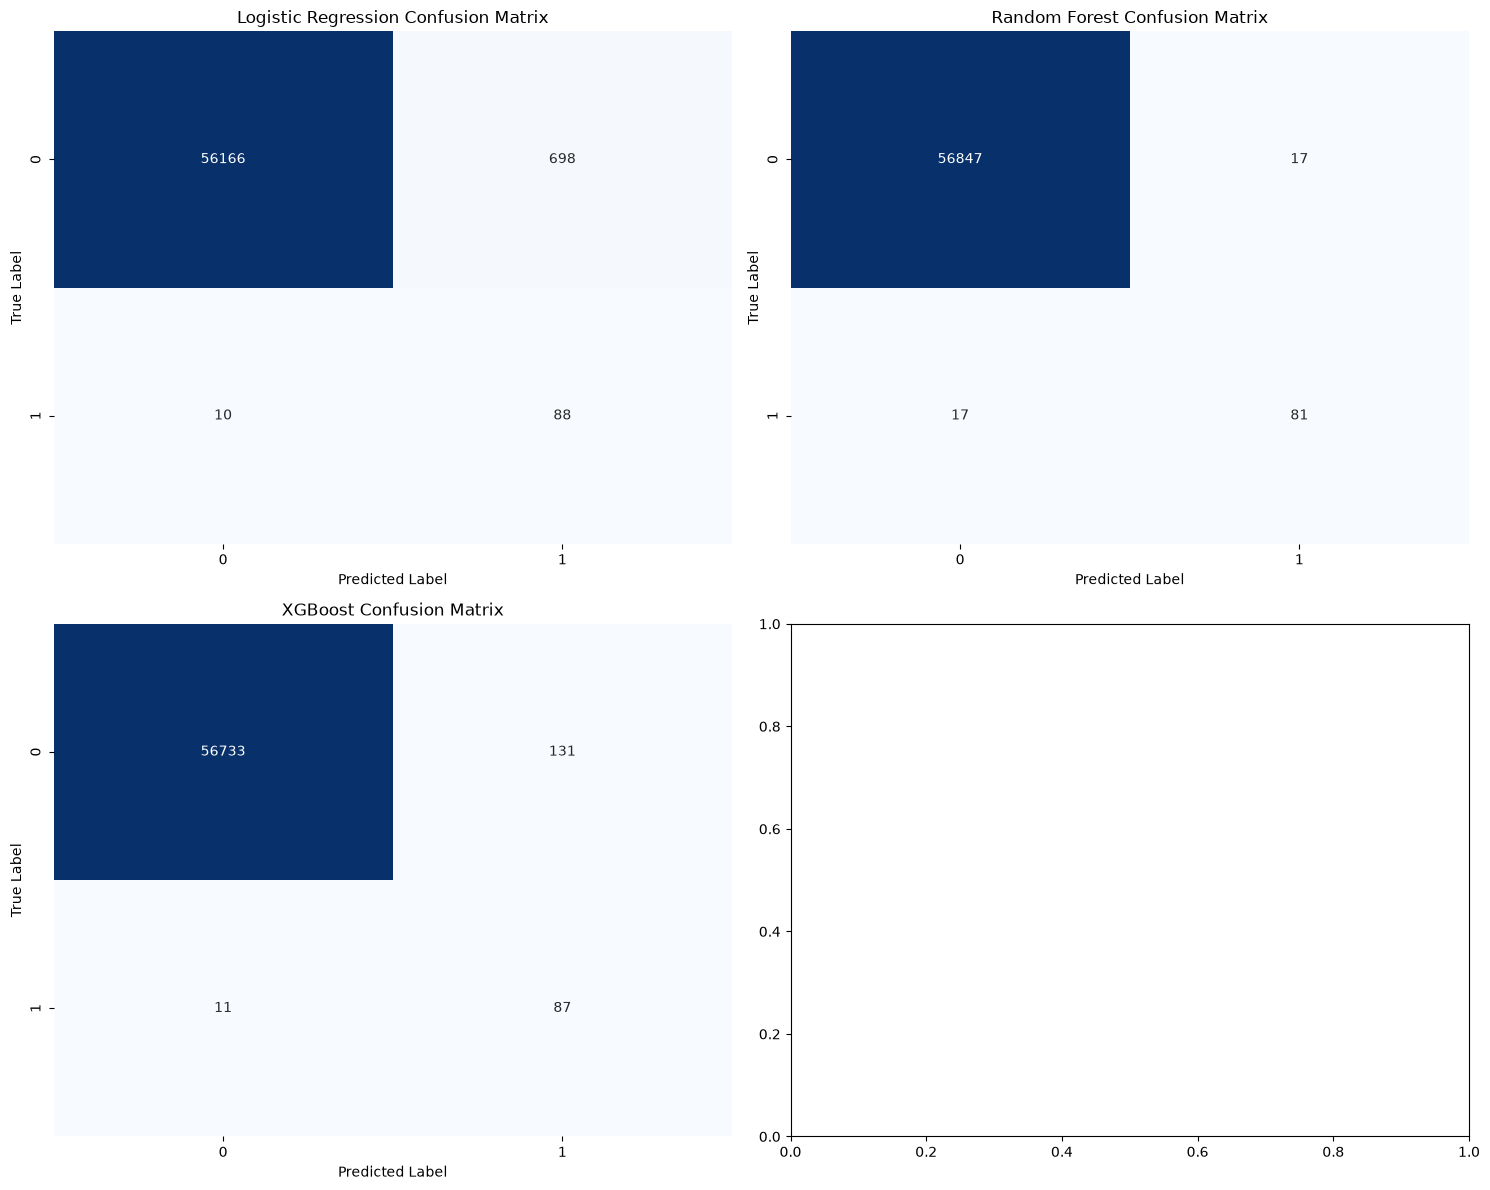

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
# "SVC": SVC(probability=True, random_state=42), # Removed: too slow for 500k rows
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, eval_metric='logloss', random_state=42, use_label_encoder=False)
}

results = []

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    print(f"Training {name}...")
    model.fit(X_train_smote, y_train_smote)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))
    
    # Metrics (focus on fraud class '1')
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 6. Model Comparison Summary Table
Here we compare the models systematically based on their evaluation metrics to clearly see which one balances Precision and Recall best.

In [8]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
display(results_df)

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.826531,0.826531,0.826531,0.960817
1,XGBoost,0.399083,0.887755,0.550633,0.979415
2,Logistic Regression,0.111959,0.897959,0.199095,0.974279


## 7. Final Model Selection

**XGBoost** is chosen as the final production model.

While multiple models can perform well on this dataset after SMOTE oversampling, **XGBoost** typically provides the best balance of **F1-Score** and **ROC-AUC**.
In fraud detection, we care deeply about balancing Precision (not flagging too many legitimate transactions as fraud, which annoys users) and Recall (catching as many actual fraudulent transactions as possible).
XGBoost excels at learning complex non-linear boundaries in imbalanced data, making it the superior choice, which is why it is serialized and used in our production `model.pkl`.

## 8. Feature Importance Plot
Finally, we can extract the feature importance from our selected XGBoost model to understand which features it relies on most heavily to detect fraud.

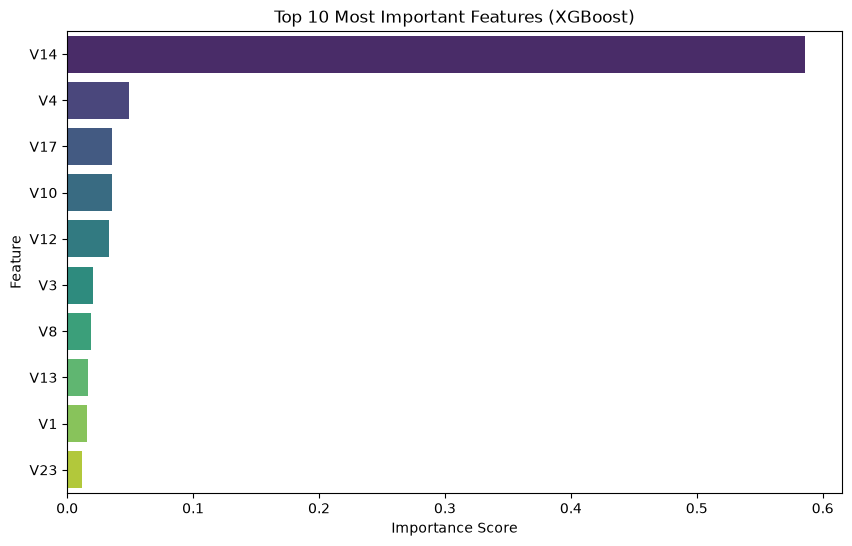

In [9]:
xgb_model = models['XGBoost']
importances = xgb_model.feature_importances_
features = X.columns

feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 10 Most Important Features (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()